# Mcardiac_EA preprocess

Prepare the data for training.


## Settings


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "experiments").is_dir() and (path / "lrpairs").is_dir())
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

scanvi_train_kwargs = {"accelerator": "gpu", "devices": 1, "enable_progress_bar": False}
from pathlib import Path
import sys
import yaml
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / "Mcardiac_EA"

CONFIG = yaml.safe_load((EXPERIMENT_DIR / "config.yaml").read_text())
def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else EXPERIMENT_DIR / path


from _shared.preprocess_plots import annotation_palette, sample_panels, alignment_overlay, embedding_panels


## Prepare data


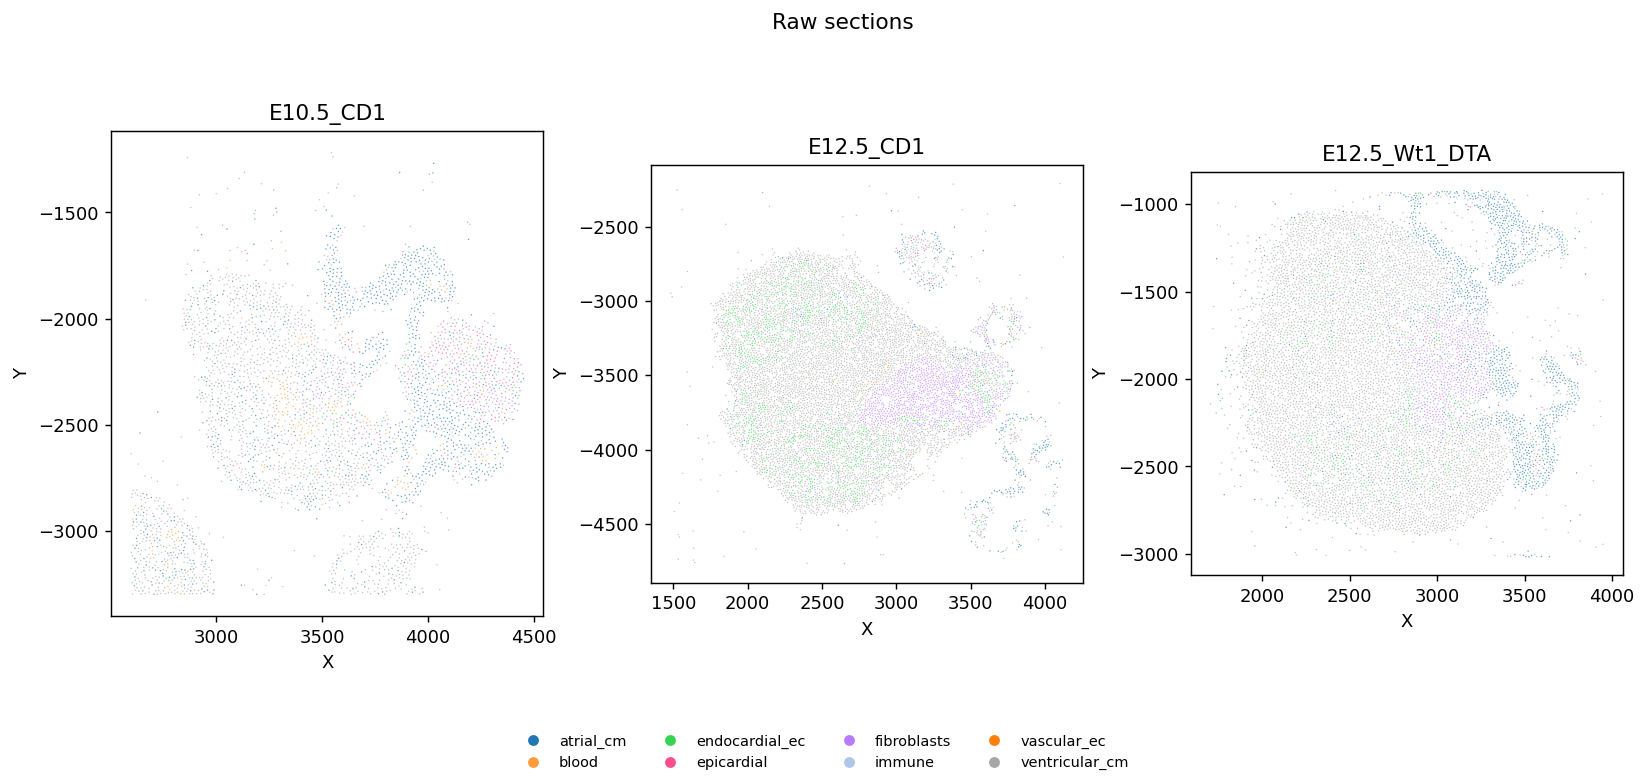

In [2]:
import json
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
from matplotlib.path import Path as Polygon
from sklearn.neighbors import NearestNeighbors
FILES = {
    "E10.5_CD1": "GSM9065770_SlideSeq_e10.5_1",
    "E12.5_CD1": "GSM8645803_SlideSeq_e12_2",
    "E12.5_Wt1_DTA": "GSM8645808_SlideSeq_e12_wt1dta_1",
}
polygons = json.loads((EXPERIMENT_DIR / "roi_polygons.json").read_text())
output = experiment_path(CONFIG["preprocess_output"])
output.mkdir(parents=True, exist_ok=True)
raw_pieces = {}
for group, stem in FILES.items():
    a = sc.read_h5ad(experiment_path(CONFIG["raw_data_dir"]) / f"{stem}.h5ad")
    a.var_names_make_unique()
    coord = pd.read_csv(experiment_path(CONFIG["coordinate_dir"]) / f"{stem}.csv", index_col=0).reindex(a.obs_names)
    a.obsm["spatial"] = coord[["x", "y"]].to_numpy(dtype=np.float32)
    if not np.isfinite(a.obsm["spatial"]).all():
        raise ValueError(f"Missing/nonfinite coordinates for {group}")
    a.obs["cell_type"] = a.obs["first_type"].astype(str).replace("<NA>", "unknown")
    a.obs["sample"] = group
    a.obs["group"] = group
    raw_pieces[group] = a

raw_view = ad.concat(raw_pieces, label="sample", index_unique="-", join="outer")
palette = annotation_palette(raw_view, "cell_type", EXPERIMENT_DIR / "colors.json")
sample_panels(raw_view, raw_view.obsm["spatial"], "sample", "cell_type", palette, title="Raw sections", size=.6);
del raw_view


## Quality control


In [3]:
pieces, summary = {}, []
for group, raw_adata in raw_pieces.items():
    a = raw_adata.copy()
    keep = a.obs["nCount_Spatial"].astype(float).ge(100) & a.obs["nFeature_Spatial"].astype(float).ge(50)
    if "spot_class" in a.obs:
        keep &= a.obs["spot_class"].astype(str).eq("singlet")
    a = a[keep].copy()
    if "counts" not in a.layers:
        raise KeyError(f"{group} must contain raw counts in layers['counts']")
    a.write_h5ad(output / f"{group}_qc_all_types.h5ad")
    base = a[a.obs["cell_type"].isin(["blood", "endocardial_ec", "fibroblasts", "ventricular_cm"])].copy()
    if base.n_obs < 6:
        raise ValueError(f"Too few beads for density filtering: {group}")
    distances = NearestNeighbors(n_neighbors=6).fit(base.obsm["spatial"]).kneighbors(base.obsm["spatial"])[0]
    base = base[distances[:, -1] <= 100.0].copy()
    base = base[Polygon(polygons[group]).contains_points(base.obsm["spatial"])].copy()
    if not base.n_obs:
        raise ValueError(f"ROI is empty: {group}")
    epi = a[a.obs["cell_type"].eq("epicardial")].copy()
    if epi.n_obs:
        distance = NearestNeighbors(n_neighbors=1).fit(base.obsm["spatial"]).kneighbors(epi.obsm["spatial"])[0][:, 0]
        epi = epi[distance <= 200.0].copy()
    pieces[group] = ad.concat([base, epi], join="outer", merge="same")
    summary.append({"sample": group, "base4": base.n_obs, "epicardial": epi.n_obs})
adata = ad.concat(pieces, label="sample", index_unique="-")
adata.obs["group"] = adata.obs["sample"].astype(str)
adata.write_h5ad(output / "selected5_qc.h5ad", compression="gzip")
pd.DataFrame(summary).to_csv(output / "qc_summary.csv", index=False)

del raw_pieces


## Train scanVI


Seed set to 2025


INFO     Training for 400 epochs.                                                                                  


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=207` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=400` reached.


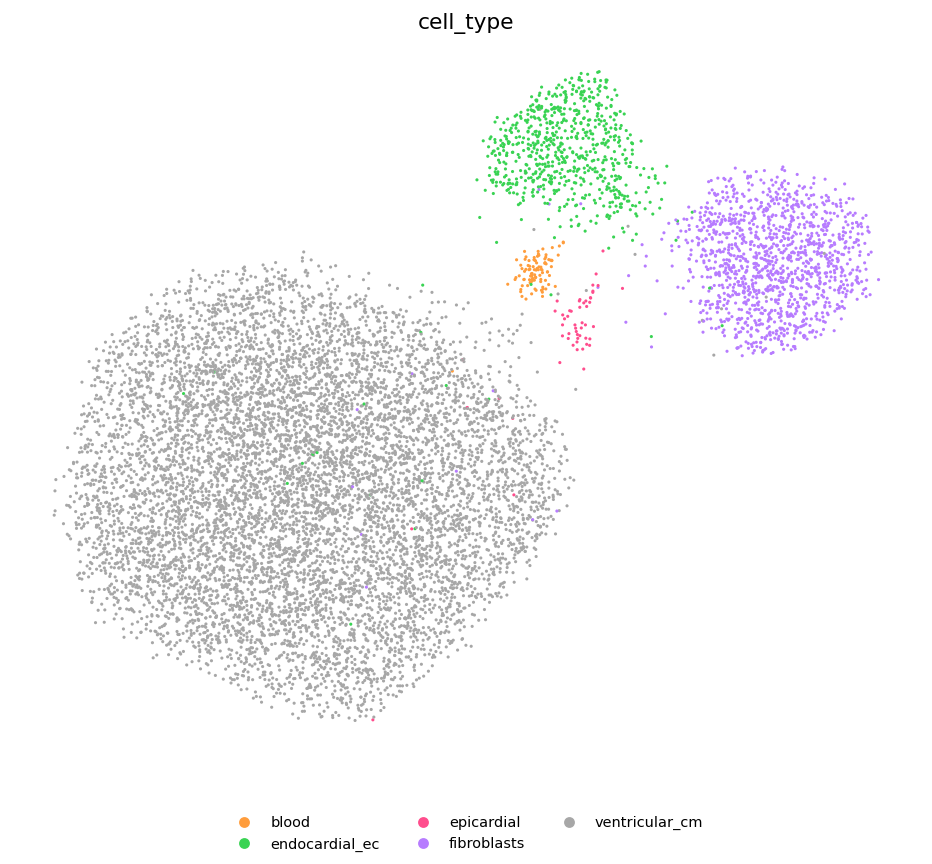

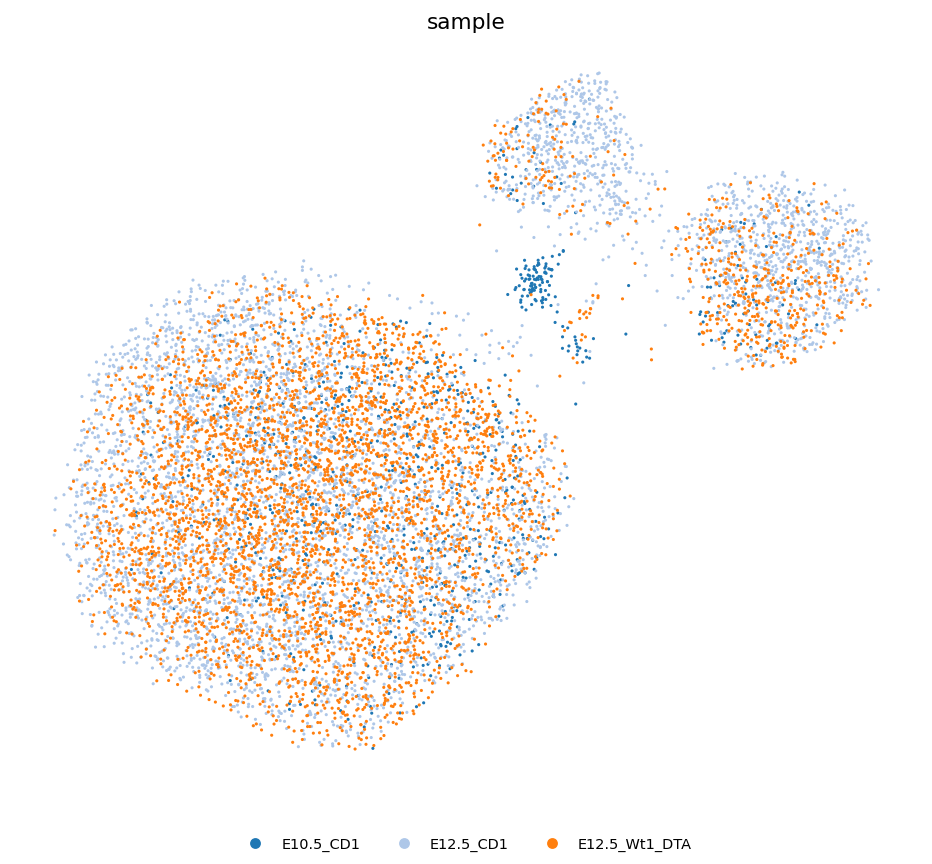

In [4]:
import scvi
import torch
from stvirtual.models import uot_alignment as uot
from stvirtual.data.contracts import canonicalize_celltypes
scvi.settings.seed = 2025
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
if "unknown" not in adata.obs["cell_type"].cat.categories:
    adata.obs["cell_type"] = adata.obs["cell_type"].cat.add_categories(["unknown"])
scvi.model.SCANVI.setup_anndata(adata, layer="counts", labels_key="cell_type", unlabeled_category="unknown", batch_key="sample")
model = scvi.model.SCANVI(adata, n_latent=10)
model.train(accelerator="gpu" if torch.cuda.is_available() else "cpu", devices=1, enable_progress_bar=False)
adata.obsm[CONFIG["latent_key"]] = model.get_latent_representation().astype(np.float32)
sc.pp.neighbors(adata, use_rep=CONFIG["latent_key"])
sc.tl.umap(adata)
embedding_panels(adata, ["cell_type", "sample"], EXPERIMENT_DIR / "colors.json");


## Spatial alignment


In [5]:
labels = adata.obs["sample"].astype(str).to_numpy()
before = np.asarray(adata.obsm["spatial"], dtype=np.float64).copy()
after = before.copy()
ref = labels == "E12.5_CD1"
transforms = {}
for group in FILES:
    if group == "E12.5_CD1":
        continue
    mask = labels == group
    after[mask], info = uot.register_slice_to_ref_robust(
        before[mask], before[ref],
        ann_src=adata.obs.loc[mask, "cell_type"].astype(str).to_numpy(),
        ann_ref=adata.obs.loc[ref, "cell_type"].astype(str).to_numpy(),
        n_sub=min(4000, mask.sum(), ref.sum()), n_starts=6, seed=2025, verbose=True,
    )
    transforms[group] = info
if not np.isfinite(after).all():
    raise ValueError("Alignment produced nonfinite coordinates")
adata.obsm["spatial_unaligned"] = before.astype(np.float32)
adata.obsm["spatial_aligned"] = after.astype(np.float32)
adata.obsm["spatial"] = after.astype(np.float32)
adata.obs["cx_aligned"], adata.obs["cy_aligned"] = after[:, 0], after[:, 1]
def jsonable(value):
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, np.generic): return value.item()
    if isinstance(value, dict): return {str(k): jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [jsonable(v) for v in value]
    return value
(output / "alignment_transforms.json").write_text(json.dumps(jsonable(transforms), indent=2))


UOT init:   0%|          | 0/18 [00:00<?, ?it/s]

UOT init:   0%|          | 0/18 [00:00<?, ?it/s, best=9.575, reg=1.03e+04, score=9.575, th=0.00077, trial=1]

UOT init:   0%|          | 0/18 [00:00<?, ?it/s, best=8.884, reg=2.05e+04, score=8.884, th=0.00655, trial=2]

UOT init:   0%|          | 0/18 [00:00<?, ?it/s, best=8.884, reg=4.11e+04, score=11.64, th=0.00497, trial=3]

UOT init:   0%|          | 0/18 [00:00<?, ?it/s, best=8.143, reg=1.03e+04, score=8.143, th=0.0044, trial=4] 

...

ICP refine:  92%|█████████▎| 37/40 [00:00<00:00, 77.14it/s, cls=1, med=11.04, p90=62.03, th=0.0125, tx=7.78, ty=1.6e+03]

ICP refine:  92%|█████████▎| 37/40 [00:00<00:00, 77.14it/s, cls=1, med=11.08, p90=62.09, th=0.0128, tx=6.7, ty=1.6e+03] 

ICP refine:  92%|█████████▎| 37/40 [00:00<00:00, 77.14it/s, cls=1, med=11.15, p90=62.08, th=0.0131, tx=5.62, ty=1.6e+03]

ICP refine: 100%|██████████| 40/40 [00:00<00:00, 78.32it/s, cls=1, med=11.15, p90=62.08, th=0.0131, tx=5.62, ty=1.6e+03]

7703

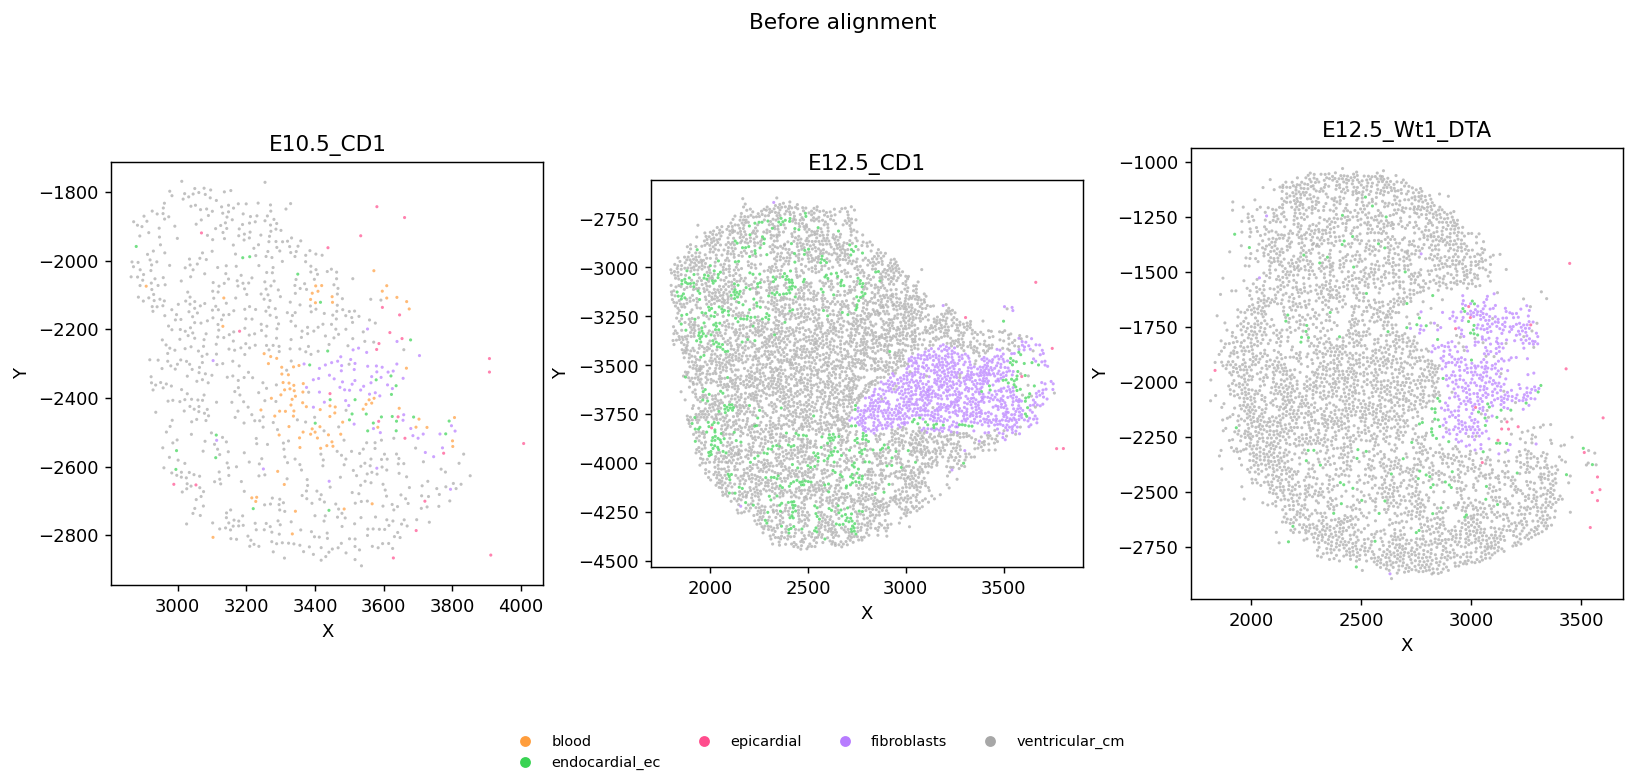

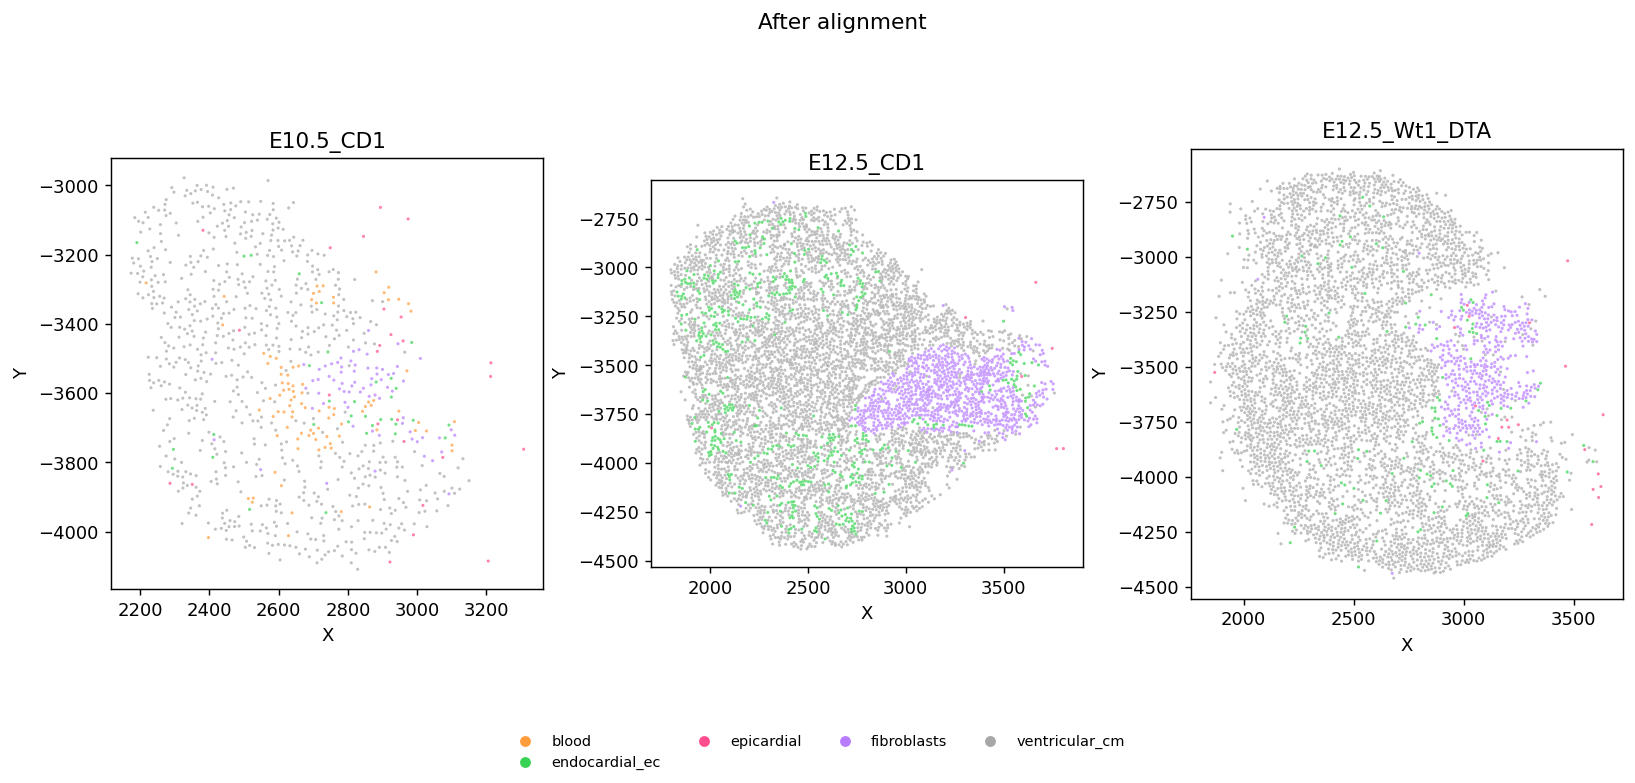

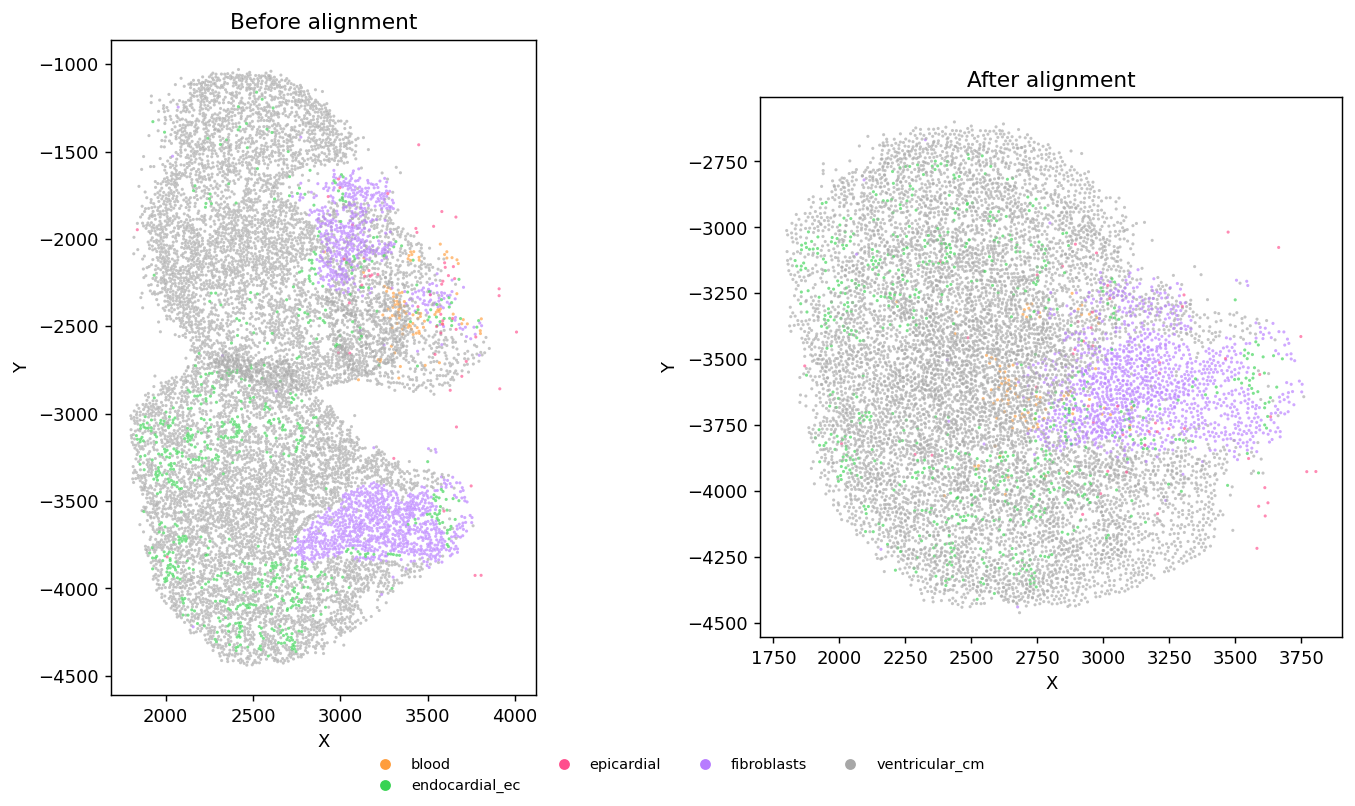

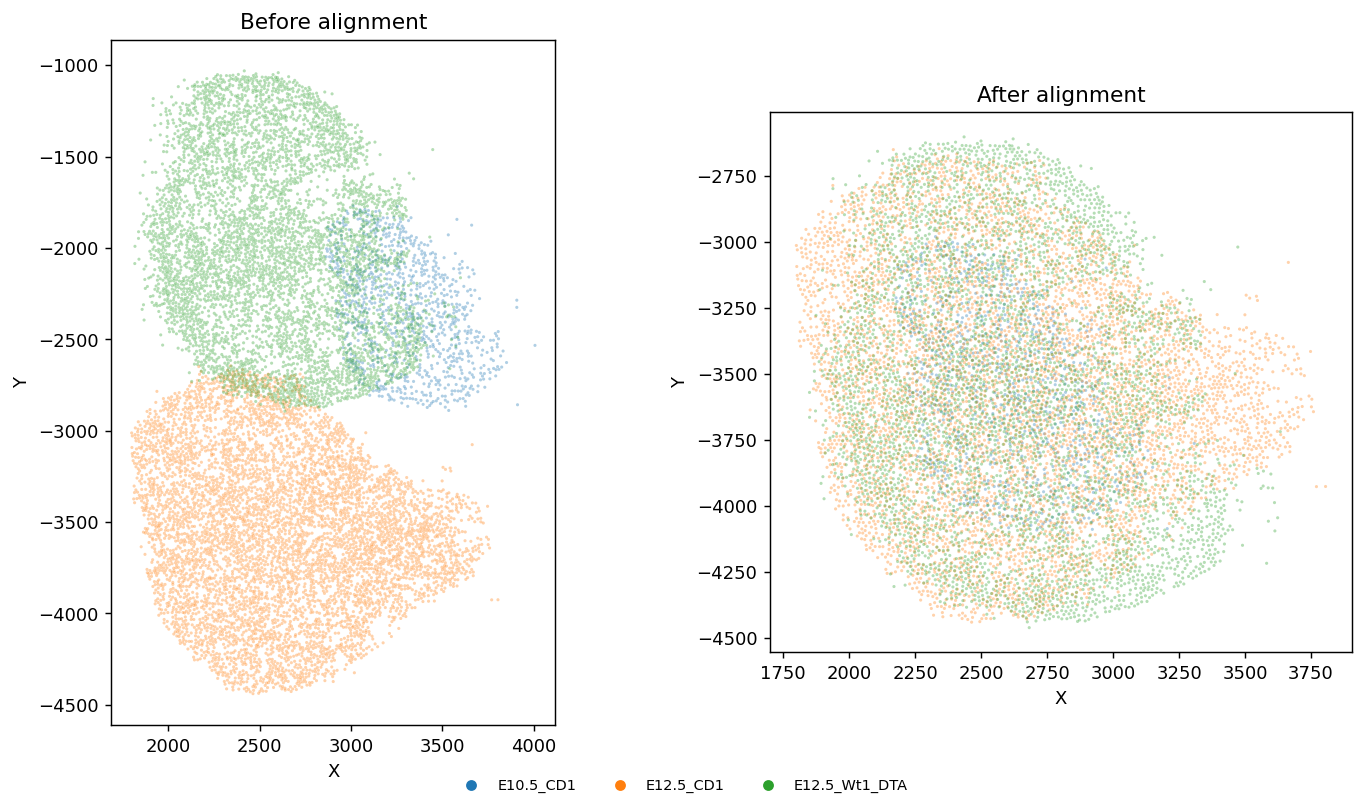

In [6]:
palette = annotation_palette(adata, 'cell_type', EXPERIMENT_DIR / "colors.json")
sample_panels(adata, before, 'sample', 'cell_type', palette, title="Before alignment", dimension=2, flip_y=True, size=3);
sample_panels(adata, after, 'sample', 'cell_type', palette, title="After alignment", dimension=2, flip_y=True, size=3);
alignment_overlay(adata, before, after, 'sample', 'cell_type', palette, dimension=2, flip_y=True, size=3);
alignment_overlay(adata, before, after, 'sample', 'cell_type', palette, dimension=2, flip_y=True, size=3, by_sample=True);


## Save input


In [7]:
mapping = canonicalize_celltypes(adata, source_key="cell_type")
scanvi_dir = experiment_path(CONFIG["scanvi_dir"])
scanvi_dir.mkdir(parents=True, exist_ok=True)
model.save(scanvi_dir, overwrite=True, save_anndata=True)
mapping.to_csv(scanvi_dir / "celltype_mapping.csv", index=False)
prepared_path = experiment_path(CONFIG["input_path"])
prepared_path.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(prepared_path, compression="gzip")
print("Training input:", prepared_path)


Training input: /home/zhouyj/stVirtual_tutorial/experiments/Mcardiac_EA/artifacts/checkpoints/scanvi/adata.h5ad
